In [1]:
#TODO: more comments in cell 4
''' 

    ADDER DATA ANALYSIS NOTEBOOK 2025

    this is an analysis notebook for our adder simulation data. 
    All graphs, interpritations and claims made about our reasearch at a high level is substaited here.

    Table of Contents:
        1. Documentation Cell, come here to find stuff
        2. Import Cell, all the imports needed for this notebook are specified in the import cell
        3. Helper Function Cell, all helper functions used in this notebook are defined in the helper function cell. the functions are:
            1. decimal : binary string -> decimal integer
            2. binary expansion : set of nums -> set of possible nums with one more digit appended
            3. string : list -> continous string of elements in list
            4. <ADDER>_latency : <ADDER Attributes> -> <ADDER latency>
        4. Read Cell, the data of the ADDERS simulated is read, cleaned, checked for errors and packaged in df for analysis in proceeding cells
        5. RCA latency visualization: latency histograms and scatter plots from the RCA
        
'''

' \n\n    ADDER DATA ANALYSIS NOTEBOOK 2025\n\n    this is an analysis notebook for our adder simulation data. \n    All graphs, interpritations and claims made about our reasearch at a high level is substaited here.\n\n    Table of Contents:\n        1. Documentation Cell, come here to find stuff\n        2. Import Cell, all the imports needed for this notebook are specified in the import cell\n        3. Helper Function Cell, all helper functions used in this notebook are defined in the helper function cell. the functions are:\n            1. decimal : binary string -> decimal integer\n            2. binary expansion : set of nums -> set of possible nums with one more digit appended\n            3. string : list -> continous string of elements in list\n            4. <ADDER>_latency : <ADDER Attributes> -> <ADDER latency>\n        4. Read Cell, the data of the ADDERS simulated is read, cleaned, checked for errors and packaged in df for analysis in proceeding cells\n        5. RCA lat

In [2]:
#Import Cell
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Helper Function Cell


''' takes a base 2 number 'binary' and returns the unsigned decimal encoded '''
def decimal(binary:str) -> int: return sum([int(binary[i])*(2**(len(binary) - i - 1)) for i in range(len(binary))])
decimal = np.vectorize(decimal) 

''' takes a list L of binary N numbers, returns a list of 2N binary numbers that can be formed by appending one digit to each number of L '''
def binary_expansion(L: list[list, str]) -> list[list, str]: return [i + [0] for i in L] + [i + [1] for i in L]

''' takes a list L, returns a continous string of all the elements in the list '''
def string(L: list[int, str]) -> str: 
    s = ""
    for i in L: s += str(i)
    return s

''' takes propagate signal from an RCA and returns run time assuming a gate delay is one unit of time (note: this assumes msb is on right)'''
def RCA_latency(P : str) -> int: 

    info = P.split("0") # a better rep of all the info we can gleam from the P signal
    longest_carry_chain =  max(info) # or lcc for short
    relative_indices_of_lcc = [i for i in range(len(info)) if info[i] == longest_carry_chain]
    
    for i in relative_indices_of_lcc:
        worst_index = i
        if (i != 0 and i != len(info) -1): break
    
    if(longest_carry_chain): # is there a carry chain at all
        if (0 < worst_index):
            if (worst_index < len(info) - 1):
                return 2*(len(longest_carry_chain) + 1) + 1 # common case
            else:
                return 2*(len(longest_carry_chain) + 1) # tail edge case
        else:
            if (worst_index < len(info) - 1):
                return 2*(len(longest_carry_chain)) + 1 # head edge case
            else:
                return 2*(len(longest_carry_chain)) # tail and head edgge case
    else:
        return 2 + (len(P) > 1)#no carry chain

In [4]:
#Read Cell
data = {}


#RCA
RCA_df = pd.read_csv("RCA.csv") 
RCA_df["P"] = ["0"*(RCA_df["N"][i] - len(str(RCA_df["P"][i]))) + str(RCA_df["P"][i]) for i in range(len(RCA_df))] #width correction of P by ZEXTing 
assert((RCA_df.Latency == [RCA_latency(p[::-1]) for p in RCA_df["P"]]).all())

#common stimulus
data["A_binary"] = np.array([str(a) for a in RCA_df[RCA_df["N"] == 32]["A"]])
data["A_decimal"] = decimal(data["A_binary"])
data["B_binary"] = np.array([str(a) for a in RCA_df[RCA_df["N"] == 32]["B"]])
data["B_decimal"] = decimal(data["B_binary"])
data["Cin"] = np.array(RCA_df[RCA_df["N"] == 32]["Cin"])

RCA_dict = {f"RCA_latency_{i}": np.array(RCA_df[RCA_df["N"] == i]["Latency"]) for i in range(1,33)}
data.update(RCA_dict)


#DRCA

#CRCA
CRCA_df = pd.read_csv("CRCA.csv")
#RCLA

#CRCLA

#KSA

#BKA

#other cooler more modern adders

df = pd.DataFrame(data)
df

,A_binary,A_decimal,B_binary,B_decimal,Cin,RCA_latency_1,RCA_latency_2,RCA_latency_3,RCA_latency_4,RCA_latency_5,...,RCA_latency_23,RCA_latency_24,RCA_latency_25,RCA_latency_26,RCA_latency_27,RCA_latency_28,RCA_latency_29,RCA_latency_30,RCA_latency_31,RCA_latency_32
0,10000000001011000100010000000000,2150384640,100110100001000111001101001101,646214477,0,2,3,4,6,7,...,9,9,9,9,9,9,9,9,9,9
1,11000101110101011100010010001011,3319121035,1010101100100011111100010101,179453717,1,2,4,6,8,10,...,19,19,19,19,19,19,19,19,19,19
2,1000101011000010010001110001010,1163993994,10011111010001000000110000111110,2672036926,1,2,3,4,5,5,...,13,13,13,13,13,13,13,13,13,13
3,100010000000100101110101000100,570580292,10110110011011011111010001101100,3060659308,1,2,3,3,4,5,...,13,13,13,13,13,13,13,13,13,13
4,11010010101011011001011010100101,3534591653,11010111011010000001100110101,451740469,1,2,3,3,3,4,...,7,7,7,7,7,7,7,7,7,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1011011010011001010000110110110,1531748790,10011111111011001100110000111111,2683096127,0,2,3,3,4,5,...,7,7,7,7,7,7,7,7,7,7
99996,1001111001000110001110110011110,1327701406,1000010010001111111110110000100,1112014212,0,2,4,5,5,6,...,9,9,9,9,9,9,9,9,9,9
99997,1101110011111101001000111011100,1853788636,1110111110100000011011111101111,2010134511,0,2,4,5,5,5,...,9,9,9,9,9,9,9,9,9,9
99998,10011000100101001010000000110001,2559877169,1011001101000010101100110110011,1503746483,1,2,4,5,5,5,...,15,15,15,15,15,15,15,15,15,15


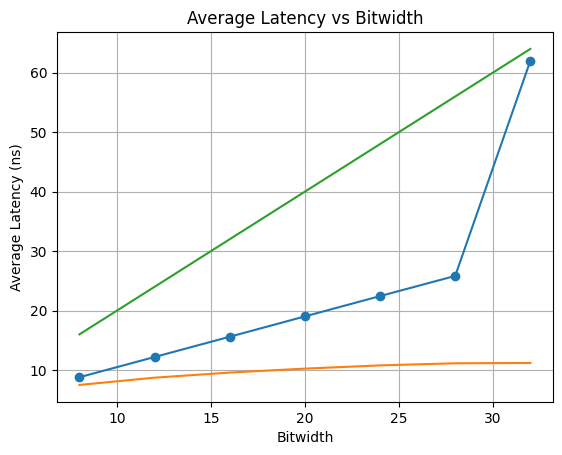

In [8]:
avg_latency = CRCA_df.groupby("bitwidth")["Latency"].mean()

plt.figure()
avg_latency.plot(marker='o')
plt.xlabel("Bitwidth")
plt.ylabel("Average Latency (ns)")
plt.title("Average Latency vs Bitwidth")
plt.grid()
plt.savefig("avg_latency.png")
plt.plot([8,12,16,20,24,28,32],[df["RCA_latency_8"].mean(), df["RCA_latency_12"].mean(), df["RCA_latency_16"].mean(), df["RCA_latency_20"].mean(), df["RCA_latency_24"].mean(), df["RCA_latency_28"].mean(), df["RCA_latency_32"].mean()])
plt.plot([8,12,16,20,24,28,32],[16,24,32,40,48,56,64])

In [9]:
avg_latency

bitwidth
8      8.79161
12    12.19435
16    15.60093
20    19.02017
24    22.43483
28    25.82741
32    62.00000
Name: Latency, dtype: float64

In [12]:
16/8.79161

1.8199169435404892

In [11]:
56/25.82741

2.1682390917246446

(array([7.6000e+02, 1.3878e+04, 0.0000e+00, 2.8195e+04, 2.4472e+04,
        0.0000e+00, 1.5372e+04, 8.3120e+03, 0.0000e+00, 4.5660e+03,
        0.0000e+00, 2.2650e+03, 1.0870e+03, 3.3000e+01, 5.4600e+02,
        2.6800e+02, 9.0000e+00, 1.0900e+02, 5.1000e+01, 4.0000e+00,
        3.9000e+01, 4.0000e+00, 1.4000e+01, 7.0000e+00, 0.0000e+00,
        7.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([ 5.        ,  6.26666667,  7.53333333,  8.8       , 10.06666667,
        11.33333333, 12.6       , 13.86666667, 15.13333333, 16.4       ,
        17.66666667, 18.93333333, 20.2       , 21.46666667, 22.73333333,
        24.        , 25.26666667, 26.53333333, 27.8       , 29.06666667,
        30.33333333, 31.6       , 32.86666667, 34.13333333, 35.4       ,
        36.66666667, 37.93333333, 39.2       , 40.46666667, 41.73333333,
        43.        ]),
 <BarContainer object of 30 artists>)

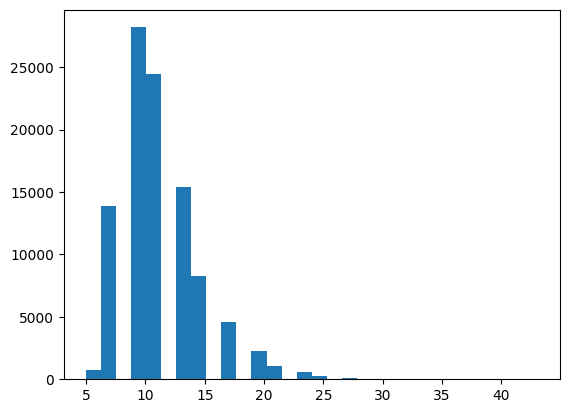

In [21]:
plt.hist(df["RCA_latency_32"], bins = 30)

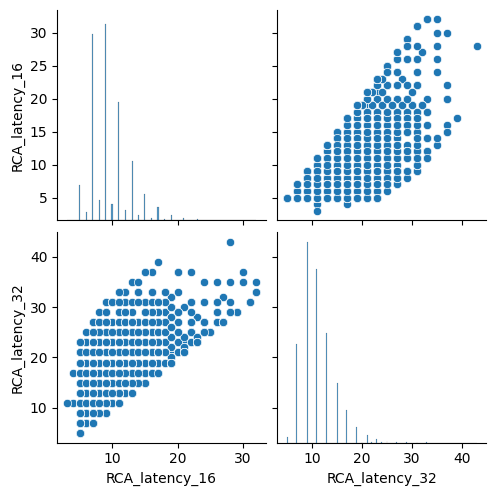

In [22]:
sns.pairplot(df[[f"RCA_latency_{i}" for i in range(16,33,16)]])

In [23]:
def time2(N):
    '''returns the time required for our design to run with the 4 input NAND peripheral 
    time is calculated based on size of the the addends (N bits)'''
    x = random.random()//(1/16)
    return N/2 + 1 if x else N

def run_simulation(save_to, runs, plot_logrithmic = False):
    ''' simulates 'runs' runs of adder designs from 1 bit to 128bit adders'''
    ROM_res = [0]
    ROM_std = []
    NAND_res = [0]
    for N in range(1,129):
        ROM_times = []
        NAND_times = []
        for j in range(runs):
            ROM_time = time([int(random.random()//0.5) for _ in range(N)])
            NAND_time = time2(N)
            ROM_times += [ROM_time]
            NAND_times += [NAND_time]
        ROM_res[-1] = sum(ROM_times)/runs
        ROM_res.append(0)
        ROM_std.append(std(ROM_times))
        NAND_res[-1] = sum(NAND_times)/runs
        NAND_res.append(0)
    plt.figure(figsize=(10,6))
    plt.plot(ROM_res[:-1], label = "our bitslice + LUT")
    plt.plot(NAND_res[:-1], label = "our bitslce + NAND")
    #plt.plot(ROM_std, label= "std of bitslice + NAND")
    plt.plot([n for n in range(1,129)], label = "normal ripple carry", c = "r")
    plt.plot([8 for _ in range(1,129)], label = "CLA")
    if plot_logrithmic: 
        plt.yscale("log")
    plt.legend()
    plt.xlabel("N bits of adder")
    plt.ylabel("Average run time over 1,000,000 runs interms of gate delays")
    plt.title("Adder Design Run Times")
    plt.savefig(save_to)

    return np.array(ROM_res), np.array(NAND_res)

In [24]:
#ROM_res, NAND_res = run_simulation("results.png", runs = 1_000_000, plot_logrithmic=False)

In [25]:
# a,b = curve_fit(logarithmic,[i for i in range(1,129)], ROM_res[:-1])[0]
# plt.figure(figsize=(10,6))
# plt.xlim(0,129)
# plt.ylim(0,10)
# plt.plot(ROM_res[:-1], label = "our design + ROM", c = "r")
# plt.plot(logarithmic(np.array([i for i in range(1,129)]),a,b), label = "logarithmic fit")
# plt.xlabel("N bits of adder")
# plt.ylabel("time interms of tbk adder")
# plt.title("design times")
# plt.legend()
# plt.savefig("logarithmic_fit.png")

In [26]:
def time3(a,b=2):
    seqs = [[]]
    for _ in range(a): seqs = binary_expansion(seqs)
    #print(f"seqs = {seqs}")
    p0 = (1/2)**b
    p1 = 1 - p0
    #print(f"p0 = {p0}, p1 = {p1}")
    ans = 0
    for seq in seqs:
        seq_time = 1
        for i in seq:
            seq_time *= p1 if i else p0
        seq_time *= (len(max(string(seq).split("1"))) + 1)/(a+1)
        ans += seq_time
    return ans

In [27]:
#7 NANDS with some logic is really not viable its speedup is barely better than 1/0.475
#15 NANDS with some logic is actually worse, so that strat doesnt even scale 
a = 15;b = 2
seqs = [[]]
for _ in range(a): seqs = binary_expansion(seqs)
#print(f"seqs = {seqs}")
p0 = (1/2)**b
p1 = 1 - p0
ans = 0
for seq in seqs:
        seq_time = 1
        for i in seq:
            seq_time *= p1 if i else p0
        seq_time *= 1/16 if seq == [1 for _ in range(15)] else 1/8 if seq.count(0) == 1 else 1/2 if seq[7] else 1
        ans += seq_time
ans

0.5918697529123165

In [28]:
((128/4)/8)*2

8.0

In [29]:
time3(7)

0.2782440185546875

In [30]:
256/218

1.1743119266055047

(0.0, 1.0)

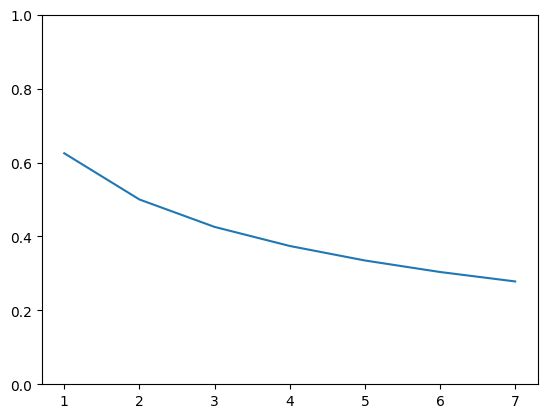

In [31]:
n = 7
#plt.plot([i for i in range(1,n+1)],[time3(i)*2**(i/8) for i in range(1,n+1)])
plt.plot([i for i in range(1,n+1)],[time3(i) for i in range(1,n+1)])
plt.ylim(0,1)

In [ ]:
runs = 100_000
res = []
for n in range(1,8):
    ans = 0
    for i in range(runs):
        ans += (len(max(string([int(random.random()//0.5) for _ in range(n)]).split("1"))) + 1)/(n+1)
    ans = ans/runs
    res.append(ans)
plt.plot([n for n in range(1,8)], res)

NameError: name 'string' is not defined

In [ ]:
def random_inputs(N):
    ''' takes an input N and returns two random N-bit numbers for the adder '''
    random_number_1 = random.getrandbits(N)
    random_number_2 = random.getrandbits(N)
    return random_number_1, random_number_2

In [3]:
def adder_time(N):
    ''' returns a random time for the adder of input N '''
    assert N>=6, "for 3 2-input NANDs, at least 6 bits are required"
    random_number_1, random_number_2 = random_inputs(N)
    propagate_chain = bin(int(random_number_1) ^ int(random_number_2))[2:].zfill(N)
    if N % 2 == 0:
        bit_positions = [[round(a*N/4 - 1), round(a*N/4 - 1) + 1] for a in range(1, 4)]
    else:
        bit_positions = [[(a*N//4) - 1, (a*N//4)] for a in range(1, 4)]
    nand_propagate = ""
    for nand_gate in bit_positions:
        input1 = nand_gate[0]
        input2 = nand_gate[1]
        nand_propagate += str(~(int(propagate_chain[input1]) & int(propagate_chain[input2])) & 0b1)
    max_time = 0
    current_time = 0
    nand_propagate += "0"
    for i in range(4):
        if i == 0:
            current_time += bit_positions[i][1]
        elif i < 3:
            current_time += bit_positions[i][1] -  bit_positions[i - 1][1]
        else:
            current_time += N - bit_positions[i - 1][1]
        if nand_propagate[i] == "1":
            if current_time > max_time:
                max_time = current_time
            current_time = 0
    if current_time > max_time:
        max_time = current_time
    return max_time + 1

In [4]:
for i in [8, 16, 32, 64, 128]:
    print(f"{i}-bit adder is {i/(sum([adder_time(i) for _ in range(10000)])/10000)} times faster than normal RCA\n")

8-bit adder is 1.8172731815910228 times faster than normal RCA

16-bit adder is 2.0422750944552233 times faster than normal RCA

32-bit adder is 2.189141856392294 times faster than normal RCA

64-bit adder is 2.2723399420553316 times faster than normal RCA

128-bit adder is 2.3215995821120754 times faster than normal RCA



NameError: name 'densities' is not defined

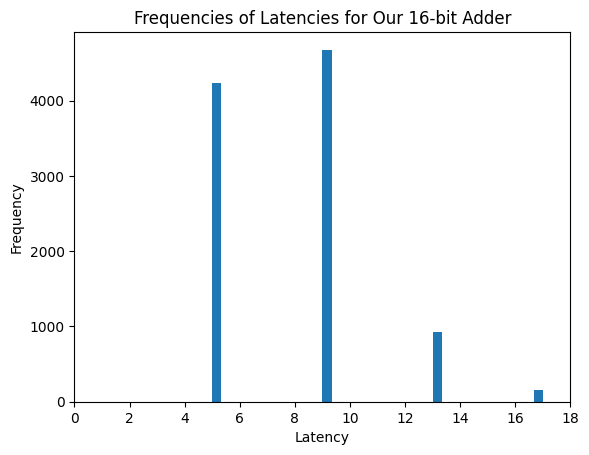

In [5]:
adder_times_16_bit = [adder_time(16) for _ in range(10000)]
plt.hist(adder_times_16_bit, bins = 36)
plt.xlim(0, 18)
plt.xlabel("Latency")
plt.ylabel("Frequency")
plt.title("Frequencies of Latencies for Our 16-bit Adder")
plt.plot()

print(f"Densities: {densities}")

Text(0.5, 1.0, 'Adder Latencies')

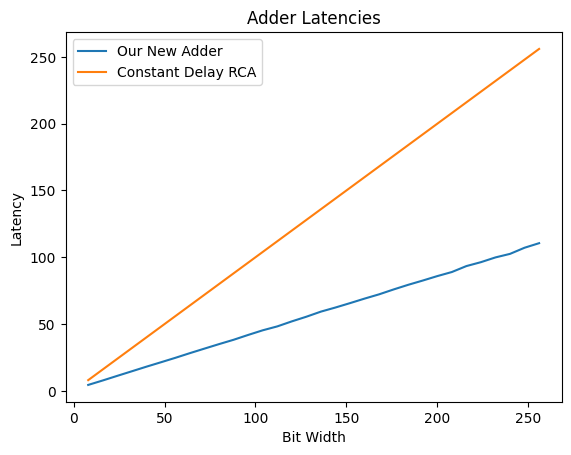

In [6]:
plt.plot([i for i in range(8, 257, 8)], [(sum([adder_time(i) for _ in range(10000)])/10000) for i in range(8, 257, 8)], label = "Our New Adder")
plt.plot([i for i in range(8, 257, 8)], [i for i in range(8, 257, 8)], label = "Constant Delay RCA")
plt.xlabel("Bit Width")
plt.ylabel("Latency")
plt.legend()
plt.title("Adder Latencies")